# BI_Project: clustering RAW Open Dataset

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from kneed import KneeLocator

In [5]:
# 1) Load
csv_path = "C:/data/GitHub/BZIA_VM/ETL/BI_Project/Open_Data_Analytics_7939237139655295132.csv"
df = pd.read_csv(csv_path)
df.head()

,Dataset,OD_ID,ObjectId,Date,Usage,SOURCE,LAST_UPDATED
0,Zoning Boundaries,OD22,2,2015-01-06 00:00:00,35,ARCGIS,2018-06-18 00:00:00
1,Solid Waste Collection Areas,OD23,3,2015-01-06 00:00:00,11,ARCGIS,2018-06-18 00:00:00
2,Street Centrelines,OD27,5,2015-01-06 00:00:00,315,ARCGIS,2018-06-18 00:00:00
3,Civic Addresses,OD3,6,2015-01-06 00:00:00,3770,ARCGIS,2018-06-18 00:00:00
4,Building Outlines,OD4,7,2015-01-06 00:00:00,341,ARCGIS,2018-06-18 00:00:00


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639106 entries, 0 to 639105
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Dataset          639106 non-null  object        
 1   OD_ID            639106 non-null  object        
 2   ObjectId         639106 non-null  int64         
 3   Date             639106 non-null  datetime64[ns]
 4   Usage            639106 non-null  int64         
 5   SOURCE           639106 non-null  object        
 6   LAST_UPDATED     639106 non-null  datetime64[ns]
 7   Date_ts          639106 non-null  int64         
 8   LAST_UPDATED_ts  639106 non-null  int64         
dtypes: datetime64[ns](2), int64(4), object(3)
memory usage: 43.9+ MB


In [11]:
# 1) Parse strings to pandas datetime
for col in ["Date", "LAST_UPDATED"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")  # coerce bad strings to NaT

# 2) Turn datetimes into numeric (Unix time in seconds, or use .view('int64') for ns)
for col in ["Date", "LAST_UPDATED"]:
    if col in df.columns and pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col + "_ts"] = df[col].view("int64") // 10**9   # seconds since epoch
        # Alternatively, milliseconds:
        # df[col + "_ms"] = df[col].view("int64") // 10**6

C:\Users\biauser\AppData\Local\Temp\ipykernel_5608\926703877.py:9: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df[col + "_ts"] = df[col].view("int64") // 10**9   # seconds since epoch
C:\Users\biauser\AppData\Local\Temp\ipykernel_5608\926703877.py:9: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df[col + "_ts"] = df[col].view("int64") // 10**9   # seconds since epoch


In [12]:
# 2) Select numeric features (must match your SQL view)
numeric_features = [
    "Date",
    "Usage",
    "LAST_UPDATED"
]


In [13]:
numeric_features = ["Usage"]
if "Date_ts" in df.columns: numeric_features.append("Date_ts")
if "LAST_UPDATED_ts" in df.columns: numeric_features.append("LAST_UPDATED_ts")

X = df[numeric_features].copy()

# Optional: clean infinities / NaNs
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)


In [14]:
# 3) Scale
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

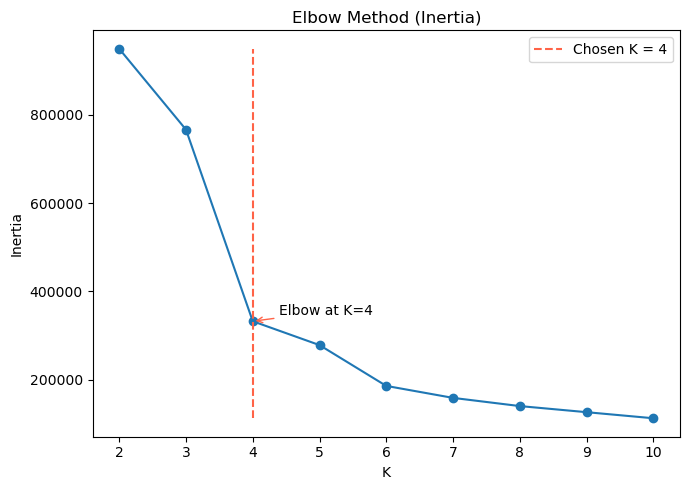

K  Inertia        Rel. drop vs prev (%)
2     949485.07          -
3     766416.63       19.3
4     332415.84       56.6
5     278406.62       16.2
6     185956.82       33.2
7     158841.52       14.6
8     140299.00       11.7
9     126462.04        9.9
10    112709.76       10.9

[INFO] Selected K by 'max-drop' elbow: 4


In [16]:

# 4) Elbow with annotation

# Range of K to evaluate
Ks = list(range(2, 11))
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init='auto', algorithm='elkan', random_state=1)
    km.fit(Xs)
    inertias.append(km.inertia_)

# Compute relative drop (%) from K to K+1
# drops[i] corresponds to % improvement going from Ks[i-1] -> Ks[i]
drops = [None]  # align indices so drops[i] relates to Ks[i]
for i in range(1, len(Ks)):
    prev, curr = inertias[i-1], inertias[i]
    drops.append((prev - curr) / prev * 100.0)

# Pick elbow as K with the **maximum** relative drop
# (largest improvement you get by adding one more cluster)
max_drop_idx = int(np.nanargmax([d if d is not None else -np.inf for d in drops]))
best_k = Ks[max_drop_idx]

# ---- Plot ----
plt.figure(figsize=(7,5))
plt.plot(Ks, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("K")
plt.ylabel("Inertia")
# Optional: uncomment for clearer visual when values span big range
# plt.yscale('log')

# Vertical line & annotation at the elbow
ymin, ymax = min(inertias), max(inertias)
plt.vlines(best_k, ymin=ymin, ymax=ymax, colors='tomato', linestyles='--', label=f"Chosen K = {best_k}")
plt.annotate(f"Elbow at K={best_k}",
             xy=(best_k, inertias[max_drop_idx]),
             xytext=(best_k + 0.4, inertias[max_drop_idx] * 1.04),
             arrowprops=dict(arrowstyle='->', color='tomato'))

plt.legend()
plt.tight_layout()
plt.show()

# Print a compact table to explain the choice
print("K  Inertia        Rel. drop vs prev (%)")
for k, I, d in zip(Ks, inertias, drops):
    if d is None:
        print(f"{k:<2} {I:>12.2f}   {'-':>8}")
    else:
        print(f"{k:<2} {I:>12.2f}   {d:>8.1f}")
print(f"\n[INFO] Selected K by 'max-drop' elbow: {best_k}")


In [17]:
# 5) Fit final model
kmeans = KMeans(n_clusters=best_k, n_init='auto', random_state=1)
df["cluster"] = kmeans.fit_predict(Xs)

cluster_labels = {
    0: "C0: Low usage · Old · Highly stale",
    1: "C1: Light to moderate · Newer · Moderately stale",
    2: "C2: Very low recent usage usage · Very old · Very stale",
    3: "C3: High usage · Mid-age (Workhorses)"
}
df["cluster_name"] = df["cluster"].map(cluster_labels)

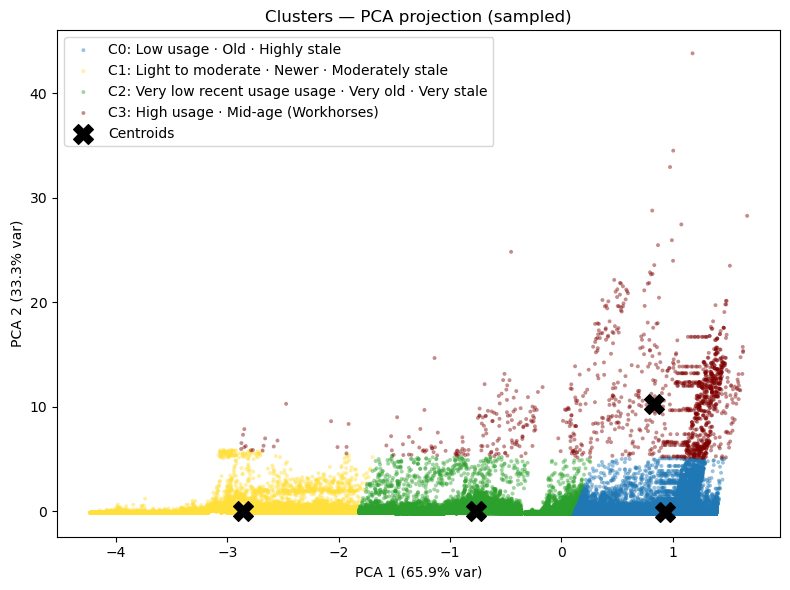

In [18]:
# 6) 2D visualization with PCA

pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(Xs)
centers_pca = pca.transform(kmeans.cluster_centers_)

# Sample for plotting only
plot_n = min(200000, len(df))
sample = df.sample(plot_n, random_state=42)
idx = sample.index
XYs = XY[idx, :]
labels_s = sample["cluster"].values
names_s = sample["cluster_name"].values

plt.figure(figsize=(8,6))
palette = ['#1f77b4','#ffdf39','#2ca02c','#7f0000']

for c in sorted(sample["cluster"].unique()):
    mask = labels_s == c
    plt.scatter(
        XYs[mask,0], XYs[mask,1],
        s=8, alpha=0.45,
        c=palette[c],
        label=cluster_labels[c],      # ← ← use full name here
        edgecolors='none'
    )

plt.scatter(
    centers_pca[:,0], centers_pca[:,1],
    c='black', s=200, marker='X',
    label="Centroids"
)

evr = pca.explained_variance_ratio_
plt.title("Clusters — PCA projection (sampled)")
plt.xlabel(f"PCA 1 ({evr[0]*100:.1f}% var)")
plt.ylabel(f"PCA 2 ({evr[1]*100:.1f}% var)")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [19]:
# 7) Cluster profiling (means)
profile = df.groupby("cluster")[numeric_features].mean().round(2)
print("\n=== Cluster Profile (feature means) ===")
print(profile)



=== Cluster Profile (feature means) ===
            Usage       Date_ts  LAST_UPDATED_ts
cluster                                         
0          540.97  1.731753e+09     1.740837e+09
1          789.31  1.525264e+09     1.547695e+09
2          703.10  1.646679e+09     1.647477e+09
3        40016.66  1.717476e+09     1.724332e+09


In [23]:
# Counts by cluster
sizes = df['cluster'].value_counts().sort_index()
share = (sizes / len(df) * 100).round(1)

# Means of numeric features
profile_mean = df.groupby("cluster")[numeric_features].mean().round(2)

# Combine
profile = profile_mean.copy()
profile.insert(0, "rows", sizes.values)
profile.insert(1, "share_%", share.values)
print("\n=== Cluster Profile (size + feature means) ===")
print(profile)


=== Cluster Profile (size + feature means) ===
           rows  share_%     Usage       Date_ts  LAST_UPDATED_ts
cluster                                                          
0        391573     61.3    540.97  1.731753e+09     1.740837e+09
1         86793     13.6    789.31  1.525264e+09     1.547695e+09
2        156627     24.5    703.10  1.646679e+09     1.647477e+09
3          4113      0.6  40016.66  1.717476e+09     1.724332e+09


In [24]:
profile_med = df.groupby("cluster")[numeric_features].median().round(2)
print("\n=== Cluster Profile (medians) ===")
print(profile_med)
'''
Name clusters:

C0: Low usage, older, very stale
C1: Low usage, newer, moderately stale
C2: Medium usage, very old, very stale
C3: Super high usage, mid‑age (your means show usage_total ≈ 40k and usage_per_365 ≈ 35k)
'''


=== Cluster Profile (medians) ===
           Usage       Date_ts  LAST_UPDATED_ts
cluster                                        
0           72.0  1.733443e+09     1.750982e+09
1          454.0  1.536278e+09     1.536451e+09
2          344.0  1.648685e+09     1.649549e+09
3        38227.0  1.729987e+09     1.750982e+09


'\nName clusters:\n\nC0: Low usage, older, very stale\nC1: Low usage, newer, moderately stale\nC2: Medium usage, very old, very stale\nC3: Super high usage, mid‑age (your means show usage_total ≈ 40k and usage_per_365 ≈ 35k)\n'

In [25]:
df.head()

,Dataset,OD_ID,ObjectId,Date,Usage,SOURCE,LAST_UPDATED,Date_ts,LAST_UPDATED_ts,cluster,cluster_name
0,Zoning Boundaries,OD22,2,2015-01-06,35,ARCGIS,2018-06-18,1420502400,1529280000,1,C1: Light to moderate · Newer · Moderately stale
1,Solid Waste Collection Areas,OD23,3,2015-01-06,11,ARCGIS,2018-06-18,1420502400,1529280000,1,C1: Light to moderate · Newer · Moderately stale
2,Street Centrelines,OD27,5,2015-01-06,315,ARCGIS,2018-06-18,1420502400,1529280000,1,C1: Light to moderate · Newer · Moderately stale
3,Civic Addresses,OD3,6,2015-01-06,3770,ARCGIS,2018-06-18,1420502400,1529280000,1,C1: Light to moderate · Newer · Moderately stale
4,Building Outlines,OD4,7,2015-01-06,341,ARCGIS,2018-06-18,1420502400,1529280000,1,C1: Light to moderate · Newer · Moderately stale


In [26]:
df.groupby("cluster_name").head(3)

,Dataset,OD_ID,ObjectId,Date,Usage,SOURCE,LAST_UPDATED,Date_ts,LAST_UPDATED_ts,cluster,cluster_name
0,Zoning Boundaries,OD22,2,2015-01-06,35,ARCGIS,2018-06-18,1420502400,1529280000,1,C1: Light to moderate · Newer · Moderately stale
1,Solid Waste Collection Areas,OD23,3,2015-01-06,11,ARCGIS,2018-06-18,1420502400,1529280000,1,C1: Light to moderate · Newer · Moderately stale
2,Street Centrelines,OD27,5,2015-01-06,315,ARCGIS,2018-06-18,1420502400,1529280000,1,C1: Light to moderate · Newer · Moderately stale
33562,Bus Routes,OD19,33565,2018-01-09,23074,ARCGIS,2018-06-18,1515456000,1529280000,3,C3: High usage · Mid-age (Workhorses)
35935,Bus Routes,OD19,35938,2018-04-16,23924,ARCGIS,2018-06-18,1523836800,1529280000,3,C3: High usage · Mid-age (Workhorses)
36719,Bus Routes,OD19,36722,2018-05-01,22908,ARCGIS,2018-06-18,1525132800,1529280000,3,C3: High usage · Mid-age (Workhorses)
85054,Boat Facilities,OD66,85057,2020-06-11,1358,ARCGIS,2020-06-14,1591833600,1592092800,2,C2: Very low recent usage usage · Very old · V...
85057,BID Area Rates,OD21,85060,2020-07-15,471,ARCGIS,2020-07-19,1594771200,1595116800,2,C2: Very low recent usage usage · Very old · V...
85124,Parking Meters,OD7,85127,2020-06-11,999,ARCGIS,2020-06-14,1591833600,1592092800,2,C2: Very low recent usage usage · Very old · V...
200004,View Planes,OD41,200007,2022-11-22,49,ARCGIS,2024-08-26,1669075200,1724630400,0,C0: Low usage · Old · Highly stale


In [27]:
df["cluster_name"].value_counts()

cluster_name
C0: Low usage · Old · Highly stale                         391573
C2: Very low recent usage usage · Very old · Very stale    156627
C1: Light to moderate · Newer · Moderately stale            86793
C3: High usage · Mid-age (Workhorses)                        4113
Name: count, dtype: int64

In [17]:
# 8) Save enriched CSV with cluster labels
out_csv = os.path.splitext(csv_path)[0] + "_with_clusters.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"\n[INFO] Exported clustered dataset to: {out_csv}")


[INFO] Exported clustered dataset to: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering_with_clusters.csv


In [18]:
df.to_csv("Open_Data_with_clusters.csv", index=False, encoding="utf-8")
df

,dataset_name,od_id,object_id,first_published_dt,last_updated_dt,usage_total,age_days,since_update_days,usage_per_365,staleness_ratio,is_arcgis,cluster,cluster_name
0,Zoning Boundaries,OD22,2,2015-01-06 00:00:00,2018-06-18 00:00:00,35,4068,2809,3.137549,0.690342,1,2,C2: Medium usage · Very old · Very stale
1,Solid Waste Collection Areas,OD23,3,2015-01-06 00:00:00,2018-06-18 00:00:00,11,4068,2809,0.986087,0.690342,1,2,C2: Medium usage · Very old · Very stale
2,Street Centrelines,OD27,5,2015-01-06 00:00:00,2018-06-18 00:00:00,315,4068,2809,28.237939,0.690342,1,2,C2: Medium usage · Very old · Very stale
3,Civic Addresses,OD3,6,2015-01-06 00:00:00,2018-06-18 00:00:00,3770,4068,2809,337.958827,0.690342,1,2,C2: Medium usage · Very old · Very stale
4,Building Outlines,OD4,7,2015-01-06 00:00:00,2018-06-18 00:00:00,341,4068,2809,30.568690,0.690342,1,2,C2: Medium usage · Very old · Very stale
...,...,...,...,...,...,...,...,...,...,...,...,...,...
639101,Horticultural Beds,OD85,639104,2025-10-18 00:00:00,2025-10-19 00:00:00,0,130,129,0.000000,0.984733,1,0,C0: Low usage · Old · Highly stale
639102,Bike Infrastructure and Suggested Routes,OD92,639105,2025-10-18 00:00:00,2025-10-19 00:00:00,54,130,129,147.474902,0.984733,1,0,C0: Low usage · Old · Highly stale
639103,Grass Inventory,OD94,639106,2025-10-18 00:00:00,2025-10-19 00:00:00,2,130,129,5.462033,0.984733,1,0,C0: Low usage · Old · Highly stale
639104,Ice Routes,OD98,639107,2025-10-18 00:00:00,2025-10-19 00:00:00,3,130,129,8.193050,0.984733,1,0,C0: Low usage · Old · Highly stale
